In [1]:
# Functions and dependencies
import numpy as np
import matplotlib.pyplot as plt
from icing_true import ICINGTrue
from icing_model import ICINGModel
from particle_filter import BootstrapParticleFilter
from ext_kalman_filter import ExtendedKalmanFilter
from utils import gen_uex_func, gen_PN_func, gen_D_func, gen_SI_func, integral_approximate_SI
rng = np.random.default_rng()

In [2]:
# Basic simulation parameters
sim_hours = 60
dt = 1.0
t = np.arange(0, sim_hours*60+1, dt) #0 to 60 hours with minute-level resolution
y0 = [5.0, 15.0, 15.0, 0.0, 0.0] #Initial conditions: G, I, Q, P1, P2
D_const = 0
SI_const = 2e-4
uex_func = gen_uex_func()
PN_func = gen_PN_func()
D_func = gen_D_func(D_const)
SI_func = gen_SI_func(SI_const)

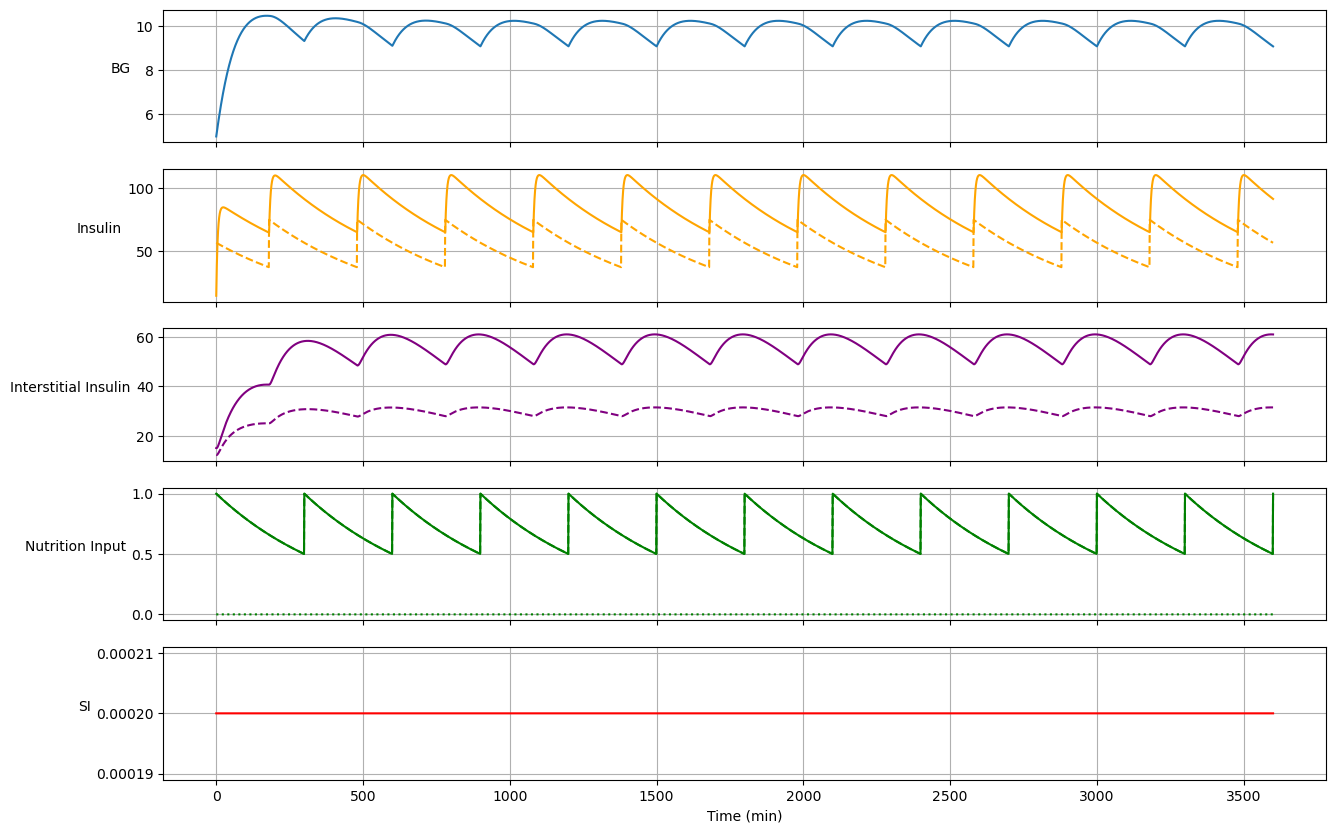

In [3]:
#  Simulation of true dynamics
gt_model = ICINGTrue()
G_true, I_true, Q_true, P1_true, P2_true, P_true = gt_model.simulate(y0, t[0], t[-1], t, uex_func, PN_func, D_func, SI_func)   
_,_ = gt_model.plot_sim()         

In [4]:
# ICING Model Initialization
Ts_meas = 120 # Period in minutes of measurement sampling
t_meas = np.arange(0, sim_hours*60+1, Ts_meas) #0 to 60 hours with minute-level resolution
sample_indices = [np.argmin(np.abs(t - st)) for st in t_meas]
measurement_noise_std = 0.25
G_meas = G_true[sample_indices] + rng.normal(0, measurement_noise_std, size=len(sample_indices))
initial_state = np.append(1.1*np.asarray(y0), [gt_model.params['k1']*np.exp(-y0[2]*gt_model.params['k2']/gt_model.params["k3"]), 2.2e-4])
initial_state = np.expand_dims(initial_state, axis=1)
process_noises = 1e-4/(Ts_meas)*np.ones((len(initial_state),))
process_noises[-1] = (1e-6)**2/(Ts_meas)
input_functions = {"D": D_func, "PN": PN_func, "Uex": uex_func}
model = ICINGModel(params=None,dt=dt, initial_state=initial_state + 0*initial_state, process_noise_vars=process_noises, measurement_noise_var=measurement_noise_std**2, u_funcs=input_functions)

In [5]:
# SI Integral Approximation
SI = []
pG = model.params["pG"]
alphaG = model.params["alphaG"]
EGP = model.params["EGP"]
CNS = model.params["CNS"]
VG = model.params["VG"]

for idx, ti in enumerate(t_meas[:-1]):
    t_mask = (t >= t[Ts_meas*idx]) & (t < t[Ts_meas*(idx+1)])
    times = t[t_mask]
    Q = Q_true[t_mask]
    P = P_true[t_mask]
    G_t1 = G_meas[idx+1]
    G_t0 = G_meas[idx]
    SI.append(integral_approximate_SI(G_t1, G_t0, Q, P, times, pG, alphaG, EGP, CNS, VG))

SI = np.reshape(SI, shape=-1)

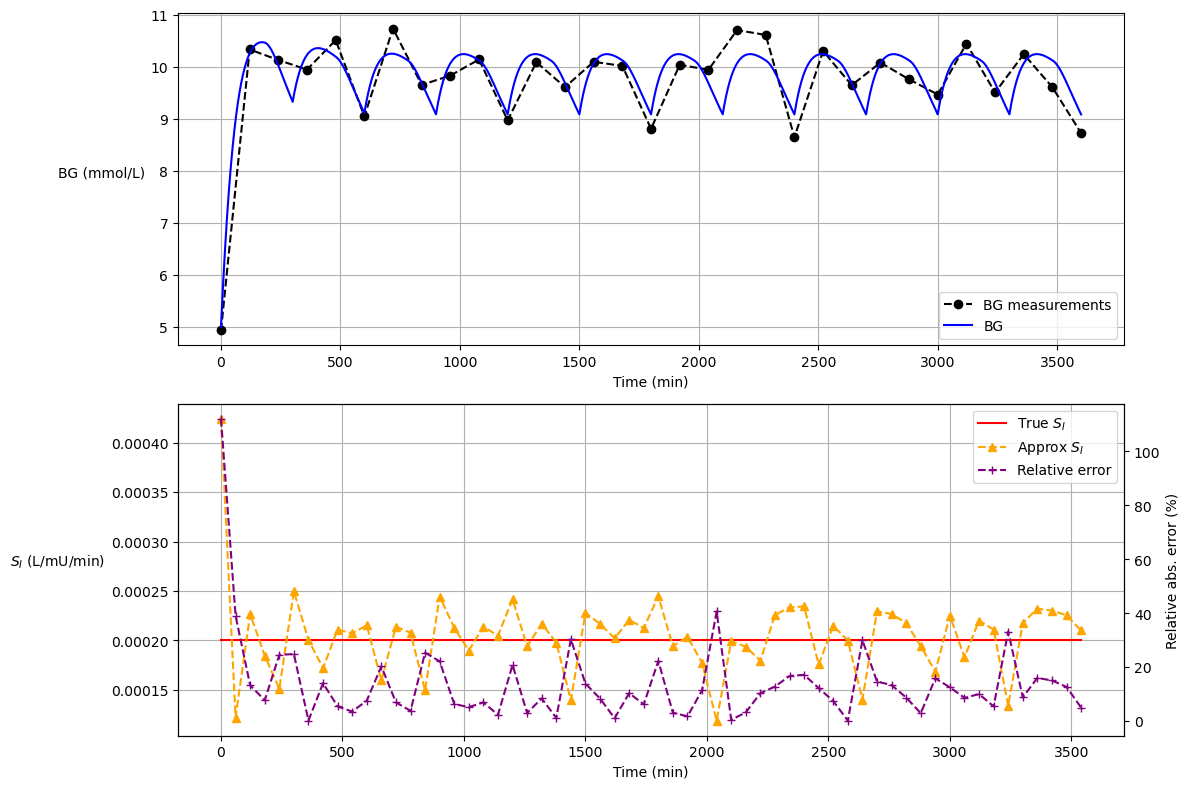

In [6]:
# Plotting SI Approximation 
SI_true = SI_const * np.ones_like(SI)
t_meas_half = np.arange(0, sim_hours*60+1, Ts_meas/2)
fig, ax = plt.subplots(2,1, figsize=(12,8))
ax[0].plot(t_meas, G_meas,  marker='o', label='BG measurements', color='k', linestyle='--')
ax[0].plot(t, G_true, label='BG', color='blue')
ax[0].set_xlabel('Time (min)')
ax[0].set_ylabel('BG (mmol/L)', rotation=0, ha="right")
ax[0].grid()
ax[0].legend()

ax[1].plot(t_meas_half[:-1], SI_true, color = 'red', label = "True $S_I$")
ax[1].plot(t_meas_half[:-1], SI, color = "orange", linestyle = '--', marker = '^', label = 'Approx $S_I$ ')
ax[1].set_xlabel("Time (min)")
ax[1].set_ylabel("$S_I$ (L/mU/min)", rotation=0, ha="right")
ax[1].grid()
err_ax = ax[1].twinx()
err_ax.spines["right"]
err_ax.plot(t_meas_half[:-1], np.abs((SI - SI_true)*100/SI_true), color="purple", linestyle = '--', marker = '+', label="Relative error")
err_ax.set_ylabel("Relative abs. error (%)")
handles1, labels1 = ax[1].get_legend_handles_labels()
handles2, labels2 = err_ax.get_legend_handles_labels()
handles = handles1 + handles2
labels = labels1 + labels2
ax[1].legend(handles, labels, loc='upper right')
fig.tight_layout()

In [7]:
# Run Extended Kalman Filter
num_states = len(initial_state)
filter = ExtendedKalmanFilter(num_states=num_states, model=model, Ts_meas=Ts_meas)
sim = filter.simulate(t, t_meas, G_meas, filter)
saved_state, saved_noise_var, G_est, Q_est, I_est, P1_est, P2_est, Uen_est, SI_est, G_pred = sim.run()

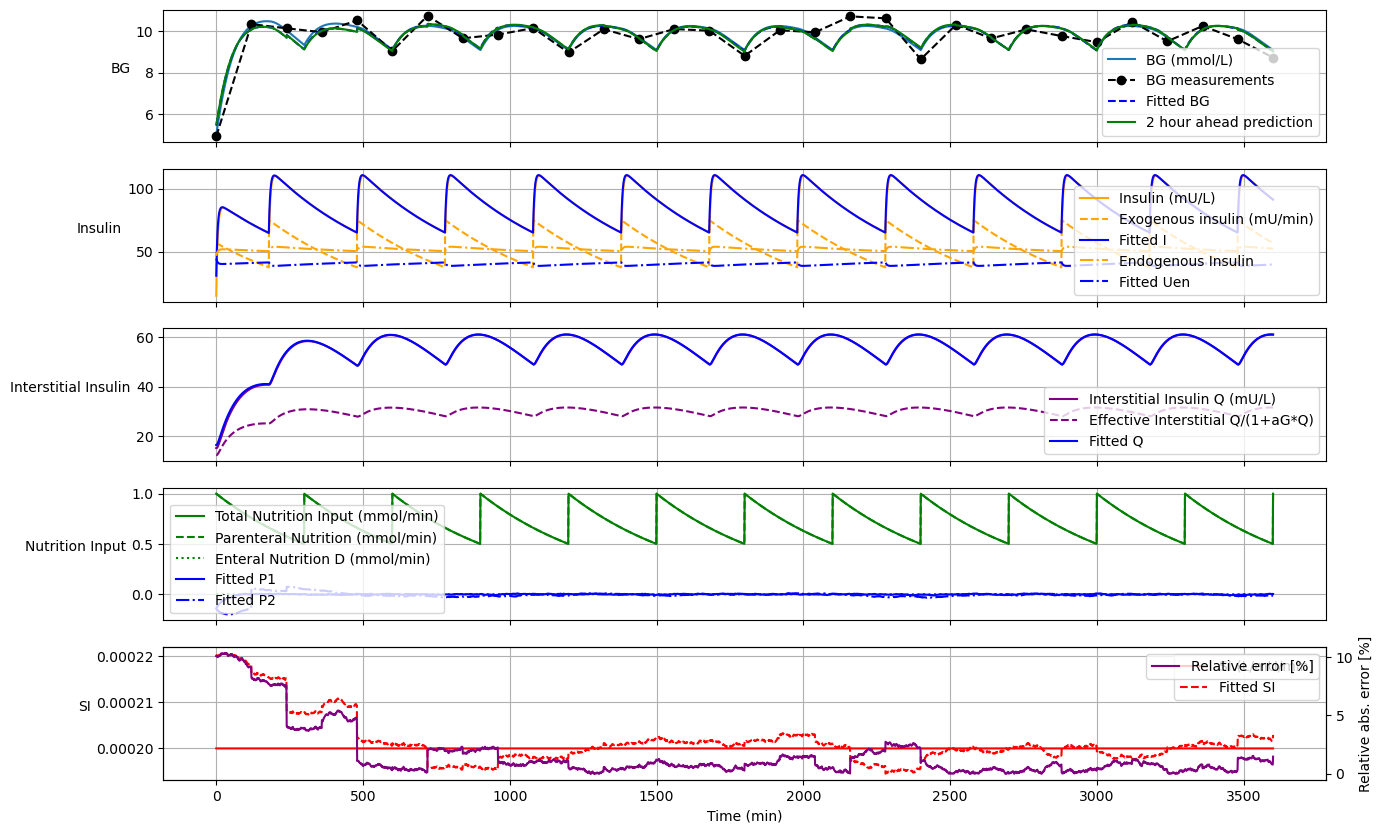

In [8]:
# Plot Extended Kalman Fitler 
sim.plot(saved_state, saved_noise_var, G_est, Q_est, I_est, P1_est, P2_est, Uen_est, SI_est, G_pred, I_true, gt_model)

In [9]:
# Run Particle Filter
num_particles = 500
filter = BootstrapParticleFilter(num_particles=num_particles, num_states=num_states, model=model, Ts_meas=Ts_meas)
sim = filter.simulate(t, t_meas, G_meas, filter)
initial_particles, initial_weights, saved_particles, saved_weights, G_est, Q_est, I_est, P1_est, P2_est, Uen_est, SI_est, G_pred = sim.run()

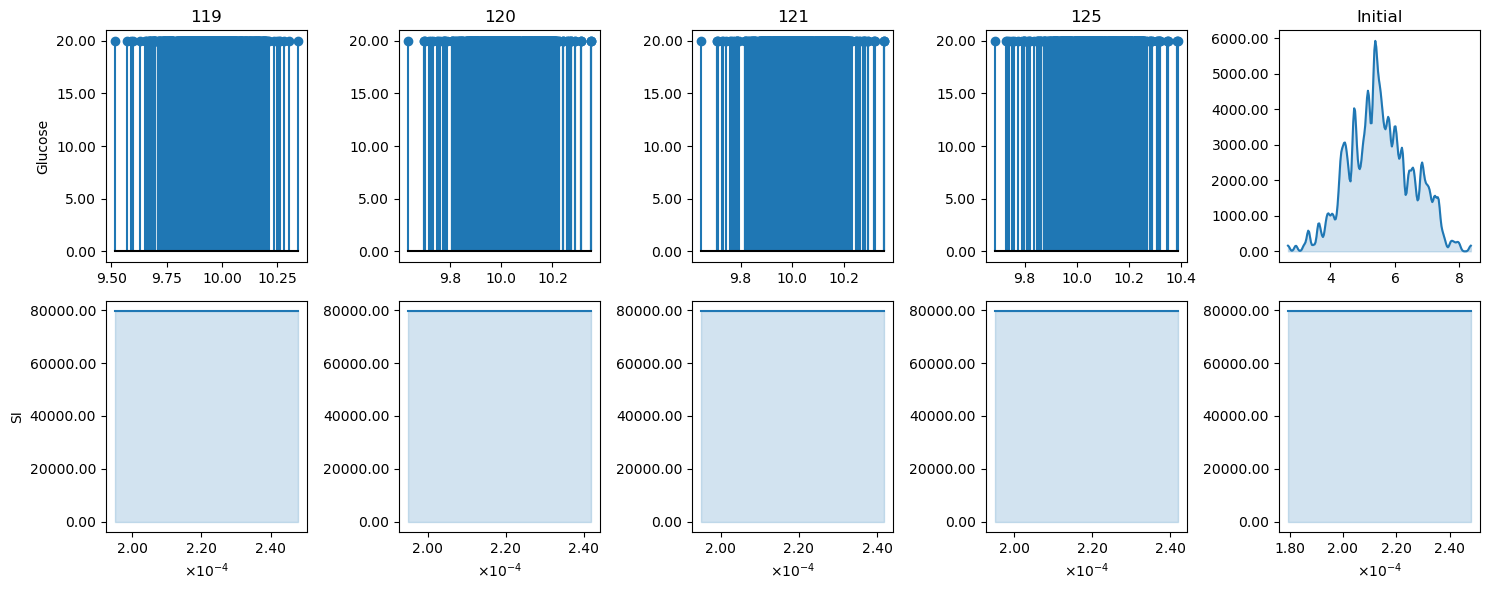

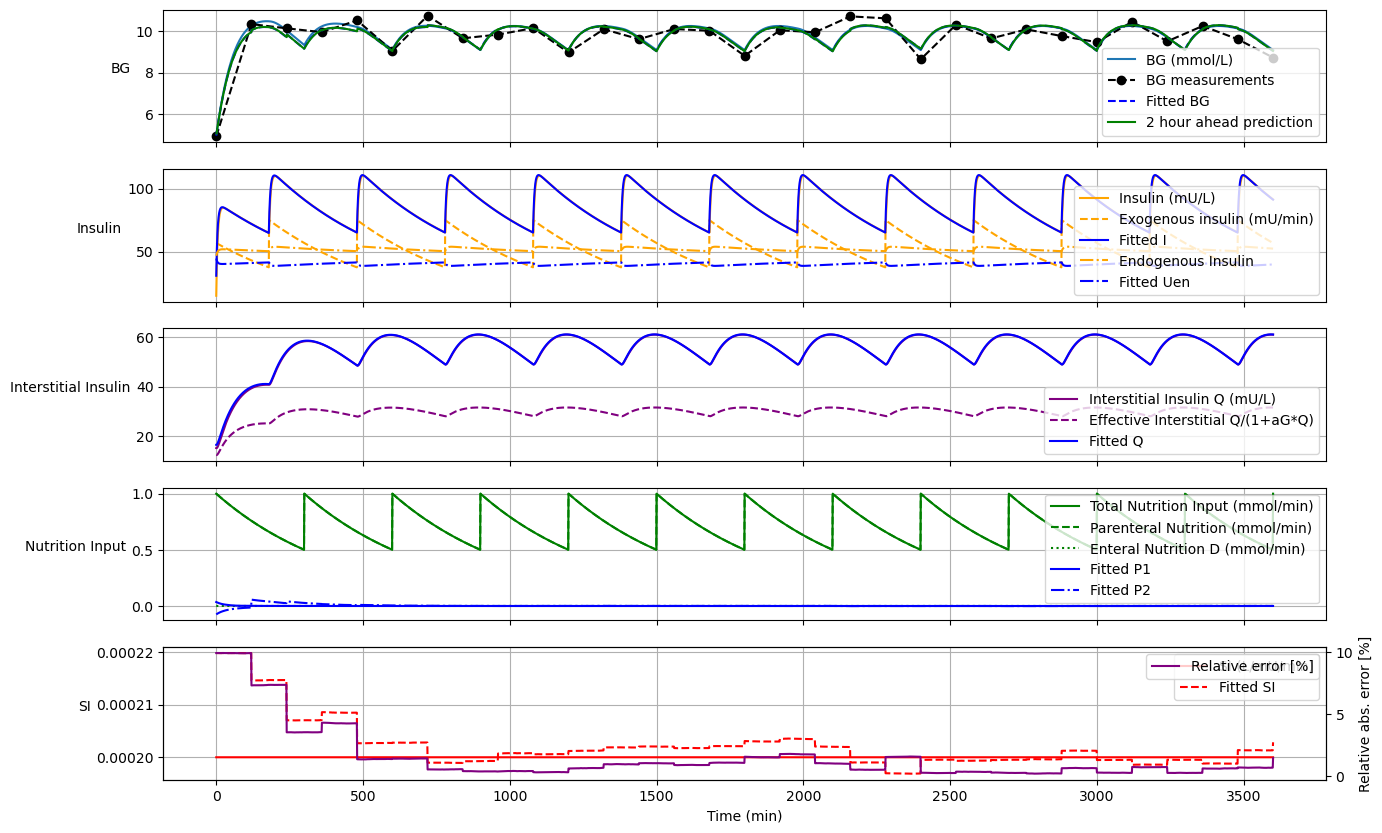

In [10]:
# Plot Particle filter
ts = [119, 120, 121, 125]
scale = 1e4
sim.plot(initial_particles, initial_weights, saved_particles, saved_weights, G_est, Q_est, I_est, P1_est, P2_est, Uen_est, SI_est, G_pred, I_true, ts, scale, gt_model)